# Task 2: California road network

**Course:** Big Data and Smart Data Analytics

**Assignment:** Task 2 - California Road Network

**Students:** Bastien Goiffon , Priscille Montoussé , Sara Silva

**Date:** 10/12/2025

## 1. Introduction to the notebook

We decided to analyze a network dataset of Californian roads. This choice was motivated by the fact that it changes from the analysis we performed with the IRA tweets dataset as it is not a social network. What we also liked is because roads are physical so feasible in an existing 3D space. The main difference with a social network as Twitter is the fact that the hedge are not directed.

The large road network comes from the Stanford SNAP repository.  
From our analysis, we found that the dataset contains:

- 1,965,206 nodes (road intersections)  
- 2,766,607 edges (undirected roads)  
- 120,676 triangles 

Our goal is to:

1. Load the dataset into Spark  
2. Preprocess the graph data  
3. Compute graph statistics  
4. Detect **graph motifs** using PySpark DataFrames
5. Compare the dataset with another one

## 2. Set up and dataloading

In this section we configure the Spark session and import the PySpark functions used throughout the notebook. We also load our  dataset _roadNet-CA.txt.gz_ and, to confirm that the file has been appropriately downloded, we examine the schema and display 5 example rows.

In [6]:
from pyspark.sql.functions import split, col, least, greatest
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import numpy as np

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 8, Finished, Available, Finished)

In [7]:
path = "abfss://dff07cf0-6894-4c9b-8be9-abbeb9cf6bd9@onelake.dfs.fabric.microsoft.com/40455879-1963-4509-b7dc-23e9d579d1dc/Files/roadNet-CA.txt.gz"

raw = spark.read.text(path)
raw_no_comments = raw.filter(~col("value").startswith("#"))

road_df = raw_no_comments.select(
    split(col("value"), r"\s+").getItem(0).cast("long").alias("src"),
    split(col("value"), r"\s+").getItem(1).cast("long").alias("dst")
)

road_df.show(5)
print("Number of raw edges:", road_df.count())

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 9, Finished, Available, Finished)

+---+---+
|src|dst|
+---+---+
|  0|  1|
|  0|  2|
|  0|469|
|  1|  0|
|  1|  6|
+---+---+
only showing top 5 rows

Number of raw edges: 5533214


The number of edges we found here is 5,533,214. It is exactly double the 2,766,607 edges we know are existing as found on the SNAP page. The problem arise from the fact that SNAP stores each undirected road as two directed lines, u - v and v - u).


###### **Clean Edges** 

To handle that, we remove self-loops (src == dst) and remove duplicate undirected edges by keeping only one of each {u,v} pair. We also cleaned and normalized the edge list by deleting the duplicates.

In [20]:
edges_clean = road_df.filter(col("src") != col("dst"))

edges_normalized = edges_clean.select(
    least(col("src"), col("dst")).alias("src"),
    greatest(col("src"), col("dst")).alias("dst")
)

edges_final = edges_normalized.dropDuplicates()

edges_final.show(5)
print("Number of edges after cleaning:", edges_final.count())

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 22, Finished, Available, Finished)

+----+-----+
| src|  dst|
+----+-----+
| 122|36184|
| 461|  462|
| 216|  308|
| 284|35846|
|2648|40749|
+----+-----+
only showing top 5 rows

Number of edges after cleaning: 2766607


After removing the self-loops, we again have a number of edges corresponding to the original SNAP dataset (2,766,607) 

We also normalized each edge by reorder the endpoints so the smallest node ID is always `src` and the largest is `dst`. This ensures `(u, v)` and `(v, u)` become identical rows.

The cleaning ensures that after the normalization, all duplicates are removed so each road appears exactly once.

## 3. Descriptive analysis

Knowing that the dataset is a network, the first analysis to perform is to understand how our network is constructed and how it can be describe in term of triangle, vertices and other similar metrics essential for motif analysis.

##### A- Road intersections

In a graph, vertices correspond to unique node identifiers. For a roads dataset, each vertex represents a **road intersection or road endpoint**.

To construct the vertex table, we extract all 'src' values, extract all 'dst' values and we merge them and, if necessary remove duplicates.

In [21]:
vertices = (
    edges_final
        .select(col("src").alias("id"))
        .union(edges_final.select(col("dst").alias("id")))
        .distinct()
)

vertices.show(5)
print("Number of vertices:", vertices.count())

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 23, Finished, Available, Finished)

+------+
|    id|
+------+
|132648|
|209614|
|210958|
|253472|
|255354|
+------+
only showing top 5 rows

Number of vertices: 1965206


This gives us exactly 1,965,206 vertices, that is to say 1,965,206 road intersection or end-point.

##### B- Possible path from an intersection

The degree of a node represents the number of road segments connected to an intersection. To understand the structure of the California Road Network, we computed the degree of every node (number of possible roads from an intersection). We also display a summary of statistics to observe how the network behave in average.

In [22]:
degree_df = (
    edges_final
        .select(col("src").alias("id"))
        .union(edges_final.select(col("dst").alias("id")))
        .groupBy("id")
        .count()
        .withColumnRenamed("count", "degree")
)

degree_df.show(10)
degree_df.describe().show()

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 24, Finished, Available, Finished)

+------+------+
|    id|degree|
+------+------+
|132648|     3|
|209614|     4|
|210958|     4|
|253472|     4|
|255354|     3|
|268479|     4|
|359663|     4|
|376979|     3|
|397545|     4|
|434909|     3|
+------+------+
only showing top 10 rows

+-------+-----------------+------------------+
|summary|               id|            degree|
+-------+-----------------+------------------+
|  count|          1965206|           1965206|
|   mean|985866.5497550893|2.8155898160294646|
| stddev|568930.6434185981|0.9946242810541788|
|    min|                0|                 1|
|    max|          1971280|                12|
+-------+-----------------+------------------+



We plotted the result by frequency to be easily observable.

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 25, Finished, Available, Finished)

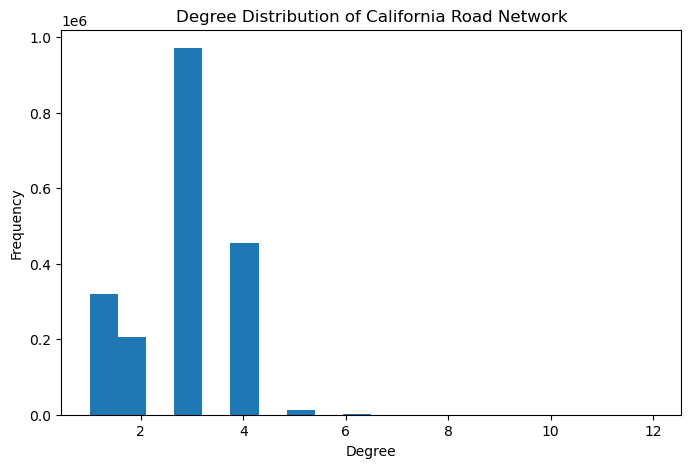

In [23]:
pdf = degree_df.select("degree").toPandas()

plt.figure(figsize=(8,5))
plt.hist(pdf["degree"], bins=20)
plt.title("Degree Distribution of California Road Network")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

In the Californian road network, most of the intersections have between degree 2 and 3 meaning that the majority are straight road or T-junctions. Without a surprise the minimum is degree 1, corresponding to a dead-end. On the contrary, the maximum is 12 and correspond to major city intersections.

These values are typical of a geographic spatial network:

- Most intersections connect 2 roads (degree = 2).  
- Many nodes are dead ends (degree = 1).  
- A few intersections act as local hubs with degree ≥ 4.  
- The highest-degree node (degree = 12) likely corresponds to a major highway junction.

This low average degree is characteristic of planar networks, where physical space limits the number of connections at each point.

We, then, wanted to know what are the to intersections so we printed the top 10 and then plotted it.

In [ ]:
top_intersections = degree_df.orderBy(col("degree").desc()).limit(10)
top_intersections.show()

StatementMeta(, 4e000a57-25f2-49e1-98e1-9cecdfe01c47, 12, Finished, Available, Finished)

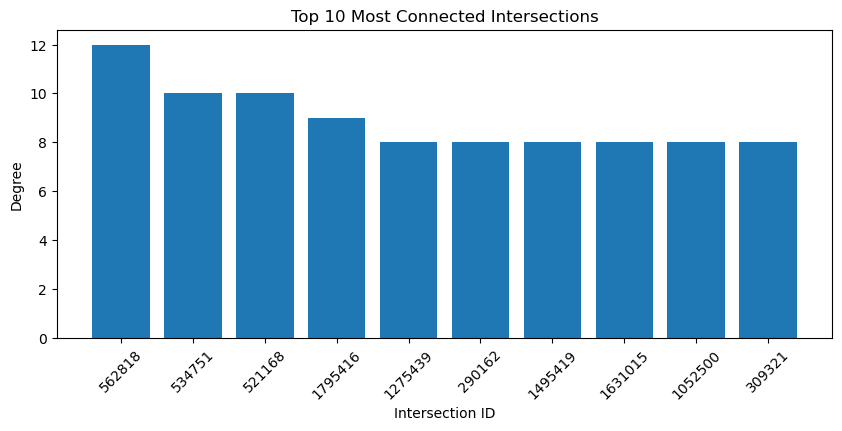

In [10]:
top20 = degree_df.orderBy(col("degree").desc()).limit(20).toPandas()

plt.figure(figsize=(10,4))
plt.bar(top10["id"].astype(str), top10["degree"])
plt.xticks(rotation=45)
plt.title("Top 10 Most Connected Intersections")
plt.xlabel("Intersection ID")
plt.ylabel("Degree")
plt.show()

Higher-degree nodes are not that frequent. That is why there is only a few with degree 12 or 10 and it decrease rapidly. It is consistent with how a road network works. Intersections with many connecting road are not the average as highway junctions or roundabouts are rare.

##### C- Connected regions

To analysis the number of connected regions containing in the network and the the width of it, we implemented the
Connected Components algorithm using iterative DataFrame operations.

Each vertex starts with its own ID as a component label. At every iteration:

1. Component labels are propagated through the edges.
2. Each vertex adopts the smallest component ID it can reach.
3. The process repeats until the labels stop changing.

In [11]:
components = vertices.withColumn("component", col("id"))

edges_undirected = edges_final.unionByName(
    edges_final.select(col("dst").alias("src"), col("src").alias("dst"))
)

changed = True
iteration = 0

while changed and iteration < 10:
    iteration += 1
    print(f"Iteration {iteration}...")

    propagated = edges_undirected.join(
        components,
        edges_undirected.src == components.id
    ).select(
        col("dst").alias("id"),
        col("component")
    )

    min_components = propagated.groupBy("id").agg(
        F.min("component").alias("new_component")
    )

    updated = components.join(min_components, "id", "left")

    changes = updated.filter(col("component") != col("new_component")).count()
    print(f"  Changes this iteration: {changes}")

    changed = changes > 0

    components = updated.withColumn(
        "component",
        F.coalesce(col("new_component"), col("component"))
    ).select("id", "component")

component_sizes = components.groupBy("component").count().orderBy(col("count").desc())
component_sizes.show(10)

StatementMeta(, 4e000a57-25f2-49e1-98e1-9cecdfe01c47, 13, Finished, Available, Finished)

Iteration 1...
  Changes this iteration: 1965206
Iteration 2...
  Changes this iteration: 1934661
Iteration 3...
  Changes this iteration: 1866421
Iteration 4...
  Changes this iteration: 1772522
Iteration 5...
  Changes this iteration: 1663481
Iteration 6...
  Changes this iteration: 1549147
Iteration 7...
  Changes this iteration: 1437326
Iteration 8...
  Changes this iteration: 1332676
Iteration 9...
  Changes this iteration: 1238651
Iteration 10...
  Changes this iteration: 1155007
+---------+-----+
|component|count|
+---------+-----+
|   832126|  737|
|  1090734|  661|
|   337325|  627|
|  1152221|  622|
|  1152241|  592|
|   496268|  583|
|   997689|  571|
|   579001|  559|
|  1500689|  558|
|  1302730|  550|
+---------+-----+
only showing top 10 rows



We also displayed it as a graph.

StatementMeta(, 4e000a57-25f2-49e1-98e1-9cecdfe01c47, 15, Finished, Available, Finished)

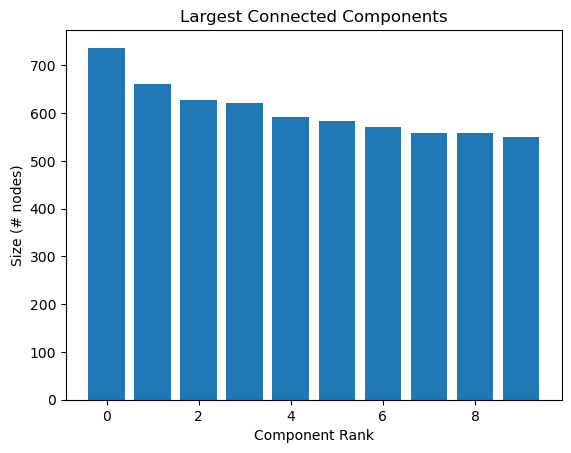

In [13]:
pdf = component_sizes.limit(10).toPandas()
plt.bar(range(len(pdf)), pdf["count"])
plt.title("Largest Connected Components")
plt.xlabel("Component Rank")
plt.ylabel("Size (# nodes)")
plt.show()

99.8% of all nodes belong to a single giant weakly connected component. Thus, if we are on a certain road or certain intersection, it is possible to reach 99.8% of the network. And only a few small disconnected parts exist (dead ends, isolated roads)

The California Road network is known to be almost fully connected as well as most of road networks, The fact that almost 100% of the nodes (intersections) are connected make sense.

##### D- Two connected road segments

In this part, we looked into the matter of 2-step paths (A → B → C). This is the first step to look at graph motifs. 

In the context of our dataset, a 2-step path corresponds to two connected road segments, forming a short chain, a road from A to B, and another from B to C.

We detect this motif with the following idea:

- join the edge table with itself  
- match the destination of the first edge (`e1.dst`) with the source of the second edge (`e2.src`)  
- extract the triple (A, B, C)

In [14]:
path2 = (
    edges_final.alias("e1")
    .join(edges_final.alias("e2"), col("e1.dst") == col("e2.src"))
    .select(
        col("e1.src").alias("A"),
        col("e1.dst").alias("B"),
        col("e2.dst").alias("C")
    )
)

print("Number of A→B→C paths:", path2.count())
path2.show(10)

StatementMeta(, 4e000a57-25f2-49e1-98e1-9cecdfe01c47, 16, Finished, Available, Finished)

Number of A→B→C paths: 3143300
+---+----+-----+
|  A|   B|    C|
+---+----+-----+
|121| 122|36184|
|116| 122|36184|
|193| 461|  462|
|435| 461|  462|
|215| 216|  308|
|214| 216|  308|
|283| 284|35846|
|446|2648|40749|
|594| 595|36020|
|607| 673|  674|
+---+----+-----+
only showing top 10 rows



The number of A → B → C paths is 3,143,300. This huge number is expected for a real road network, where most intersections connect to 2–4 neighboring intersections.

However, this result can appear a bit strange as there is only around 2.7 million edges. But here we are speaking about chains, not triangle. That is why the number of 2-step paths is greatter than the overall number of edges.

## 4. Motif detection - Triangles

An interesting motif to find in a network is triangles. In our context, triangle means that a portion of road A-B and another B-C are also connected from A to C. In concrete terms, this means that a block (district), instead of being a rectangle as we are used to, is a triangle.

We calculate the triangles by using the fact that a triangle to be closed need to follow the path A → B → C → A.

In [16]:
E1 = edges_final.alias("e1")
E2 = edges_final.alias("e2")
E3 = edges_final.alias("e3")

triangles = (
    E1.join(E2, col("e1.dst") == col("e2.src"))               # A → B and B → C
      .join(E3, (col("e2.dst") == col("e3.src")) &            # C → A
                 (col("e3.dst") == col("e1.src")))
      .select(
          col("e1.src").alias("A"),
          col("e1.dst").alias("B"),
          col("e2.dst").alias("C")
      )
)

print("Number of triangles:", triangles.count())
triangles.show(10)

StatementMeta(, 4e000a57-25f2-49e1-98e1-9cecdfe01c47, 18, Finished, Available, Finished)

Number of triangles: 0
+---+---+---+
|  A|  B|  C|
+---+---+---+
+---+---+---+



This attempt to detect triangles returned zero results. This is because, during preprocessing, we normalized each edge so that 'src < dst'. This effectively orients all edges from the smaller ID to the larger ID, making the graph acyclic. It is then impossible to have a directed cycle 'A → B → C → A' if all edges always point from lower to higher node IDs.

To correctly detect triangles and avoid this pitfall, we treat the graph as undirected and look for triplets of vertices '(a, b, c)' with 'a < b < c' such that all three edges exist:

- '(a, b)'  
- '(a, c)' 
- '(b, c)'

In [17]:
# Step 0: start from undirected unique edges: src < dst
ab = edges_final.select(
    col("src").alias("a"),
    col("dst").alias("b")
)

# Step 1: find pairs of edges sharing the same 'a': (a,b) and (a,c) with b < c
ab_ab = (
    ab.alias("ab1")
      .join(
          ab.alias("ab2"),
          (col("ab1.a") == col("ab2.a")) & (col("ab1.b") < col("ab2.b"))
      )
)

tri_candidates = ab_ab.select(
    col("ab1.a").alias("a"),
    col("ab1.b").alias("b"),
    col("ab2.b").alias("c")
)

# Step 2: keep only those where edge (b,c) also exists
triangles = (
    tri_candidates.alias("t")
      .join(
          ab.alias("bc"),
          (col("t.b") == col("bc.a")) & (col("t.c") == col("bc.b"))
      )
      .select(col("t.a").alias("a"),
              col("t.b").alias("b"),
              col("t.c").alias("c"))
      .distinct()
)

tri_count = triangles.count()
print("Number of undirected triangles:", tri_count)
triangles.show(10)



StatementMeta(, 4e000a57-25f2-49e1-98e1-9cecdfe01c47, 19, Finished, Available, Finished)

Number of undirected triangles: 120676
+-----+-----+------+
|    a|    b|     c|
+-----+-----+------+
|  917|  925|  2194|
| 5991| 6004|  6090|
| 6079| 6081|  6103|
| 8109| 8117|  8122|
|10587|10591| 10769|
|16333|16334| 16351|
|19920|19921| 20092|
|41670|41671| 41684|
|22282|40690|139771|
|26896|26897| 26898|
+-----+-----+------+
only showing top 10 rows



This time, the final triangle count is 120,676 and matches the one reported by SNAP. The number is coherent with what is observed in real life as for road triangle is not the most used patter but more rectangle (4-edge motifs).

To go deeper in the triangle motif, and is usefull to understand roads network, we looked at the number of triangle per node. In our context, it means that we are looking at the number of roads, only one intersection far and linked by 2 edges from the same intersection.

In [18]:
tri_count_by_node = triangles.groupBy("a").count().orderBy(col("count").desc())
tri_count_by_node.show(10)

StatementMeta(, 4e000a57-25f2-49e1-98e1-9cecdfe01c47, 20, Finished, Available, Finished)

+-------+-----+
|      a|count|
+-------+-----+
| 643655|    6|
| 617103|    5|
|1369453|    5|
| 988131|    5|
| 580563|    5|
| 842149|    4|
| 632542|    4|
| 133800|    4|
|1093950|    4|
|1263179|    4|
+-------+-----+
only showing top 10 rows



From the 120,676 triangle motifs detected, 6 have the same intersection (node). It decrease progressively as only 4 intersections have 5 triangles. Thus, the triangles seem to be balanced in their distribution.

**Key Takeaways**

While the network exhibits millions of simple path motifs (A → B → C), it contains a much smaller number of triangles, consistent with the sparse, planar structure of real road systems. The triangles are distributed in a fairly equitable way as the maximum number of triangles from a same node is 6 and decrease sharply.

Overall, motif detection provides insight into the topology, connectivity, and clustering characteristics of the California road network.

## 5. Comparison with another road network

##### Introduction

We decided to compare our California road dataset with another Road Network. Indeed, in addition that it was easy to do as some other datasets were available on the Stanford SNAP website under the same format, it is also an interesting work to perform as it is the same type (undirected), has the same semantics and is very similar scale. That is why we are expecting to have similar motifs.

##### Our approach

To understand whether the properties of the California road network are specific
to that state or general for US road networks, we repeat the same analysis on
another SNAP road dataset, the road network of Texas (roadNet-TX).

As for the California one, we computed:

- number of edges and vertices
- degree distribution and top intersections
- connected components
- path motifs A → B → C
- triangle motifs

Then we compare California vs Texas.

##### Analysis of the Texas road network and comparison

Firstly, we loaded the Texas dataset and then we count the number of edges. Like for the California roads dataset, we decided to work in 2 steps. We stated to count the number of edge as if the dataset was directed and then, we normalized and clean the dataset to find the number of road segment knowing it is an undirected network.

###### **Number of road segment**

In [8]:
path_tx = "abfss://dff07cf0-6894-4c9b-8be9-abbeb9cf6bd9@onelake.dfs.fabric.microsoft.com/40455879-1963-4509-b7dc-23e9d579d1dc/Files/roadNet-TX.txt.gz"

raw_tx = spark.read.text(path_tx)
raw_no_comments_tx = raw_tx.filter(~col("value").startswith("#"))

road_tx_df = raw_no_comments_tx.select(
    split(col("value"), r"\s+").getItem(0).cast("long").alias("src"),
    split(col("value"), r"\s+").getItem(1).cast("long").alias("dst")
)

road_tx_df.show(5)
print("Number of raw TX edges:", road_tx_df.count())

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 10, Finished, Available, Finished)

+---+---+
|src|dst|
+---+---+
|  0|  1|
|  0|  2|
|  0| 29|
|  1|  0|
|  1| 23|
+---+---+
only showing top 5 rows

Number of raw TX edges: 3843320


In [9]:
edges_clean_tx = road_tx_df.filter(col("src") != col("dst"))

edges_normalized_tx = edges_clean_tx.select(
    least(col("src"), col("dst")).alias("src"),
    greatest(col("src"), col("dst")).alias("dst")
)

edges_final_tx = edges_normalized_tx.dropDuplicates()

edges_final_tx.show(5)
print("Number of TX edges after cleaning:", edges_final_tx.count())

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 11, Finished, Available, Finished)

+----+----+
| src| dst|
+----+----+
|   4|  19|
|4998|5343|
| 253| 256|
|9442|9445|
| 461| 462|
+----+----+
only showing top 5 rows

Number of TX edges after cleaning: 1921660


We found that there is 1,921,660 road segments, which is less by 844,947 (more than 1/3) road segments compared to the California network. This make even if the State of Texas is bigger as the California on is known to be very well connected and having a bigger population.

###### **Number of intersections**

Here, we computed the number of nodes, meaning the intersections in the context of a road network.


In [11]:
vertices_tx = (
    edges_final_tx.select(col("src").alias("id"))
    .union(edges_final_tx.select(col("dst").alias("id")))
    .distinct()
)

vertices_tx.show(5)
print("Number of TX vertices:", vertices_tx.count())

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 13, Finished, Available, Finished)

+-----+
|   id|
+-----+
|33760|
|60913|
|63710|
|69086|
|89041|
+-----+
only showing top 5 rows

Number of TX vertices: 1379917


The number of nodes (intersections) is 1,379,917, again less than the California network as the Texas road are more sparse due to the Chihuahua desert we can found in Texas also.

###### **Connection of the intersections**

Knowing that the network is undirected, the degree of a node is the number of incident edges, regardless of whether the node appears as 'src' or 'dst'. We computed the connections between the intersections (nodes).

In [12]:
degree_tx_df = (
    edges_final_tx.select(col("src").alias("id"))
    .union(edges_final_tx.select(col("dst").alias("id")))
    .groupBy("id")
    .count()
    .withColumnRenamed("count", "degree")
)

degree_tx_df.show(10)
degree_tx_df.describe().show()

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 14, Finished, Available, Finished)

+------+------+
|    id|degree|
+------+------+
| 33760|     3|
| 60913|     4|
| 63710|     3|
| 69086|     3|
| 89041|     4|
|104529|     3|
|110193|     4|
|164615|     3|
|187706|     2|
|194117|     4|
+------+------+
only showing top 10 rows

+-------+-----------------+------------------+
|summary|               id|            degree|
+-------+-----------------+------------------+
|  count|          1379917|           1379917|
|   mean|696778.7836522051| 2.785182007323629|
| stddev|402277.9937789812|1.0054594476878687|
|    min|                0|                 1|
|    max|          1393382|                12|
+-------+-----------------+------------------+



We plotted the histogram of node degrees for the Texas road network to compare with California.

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 26, Finished, Available, Finished)

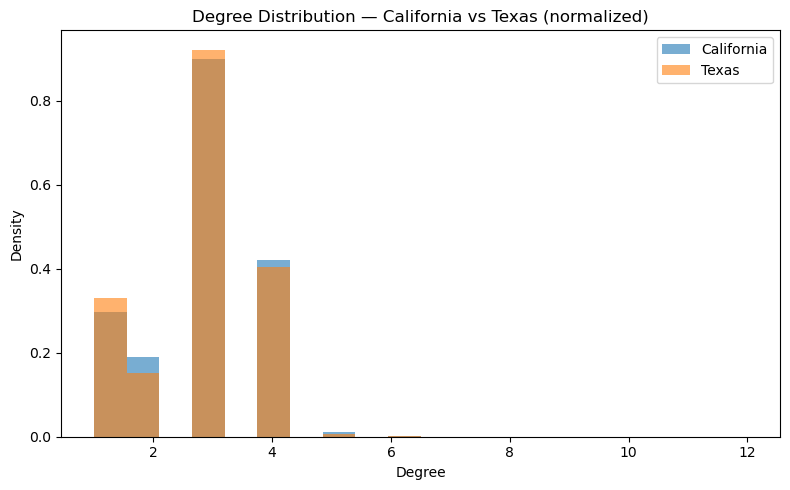

In [24]:
pdf_deg_tx = degree_tx_df.select("degree").toPandas()

deg_ca = pdf["degree"].values
deg_tx = pdf_deg_tx["degree"].values

bins = np.histogram_bin_edges(np.concatenate([deg_ca, deg_tx]), bins=20)

plt.figure(figsize=(8,5))
plt.hist(deg_ca, bins=bins, alpha=0.6, density=True, label="California")
plt.hist(deg_tx, bins=bins, alpha=0.6, density=True, label="Texas")
plt.title("Degree Distribution — California vs Texas (normalized)")
plt.xlabel("Degree")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

Both networks show low average degree and very few highly connected intersections, as expected in planar road networks. When speaking about density and not numbers, the roads networks seems very similar regarding the number of connection from an intersection.

###### **Intersections with the most connections**

After knowing that the connection between California and Texas roads behave in a similar way, we wanted to compare the most connected intersections. After computing it, we created a bar plot.

In [14]:
top_intersections_tx = degree_tx_df.orderBy(col("degree").desc()).limit(10)
top_intersections_tx.show()

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 16, Finished, Available, Finished)

+-------+------+
|     id|degree|
+-------+------+
| 468366|    12|
| 465533|    12|
| 126099|    12|
| 131052|    12|
| 133913|    12|
| 471290|     8|
| 466259|     8|
| 381523|     8|
|1127358|     8|
| 330090|     8|
+-------+------+



StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 28, Finished, Available, Finished)

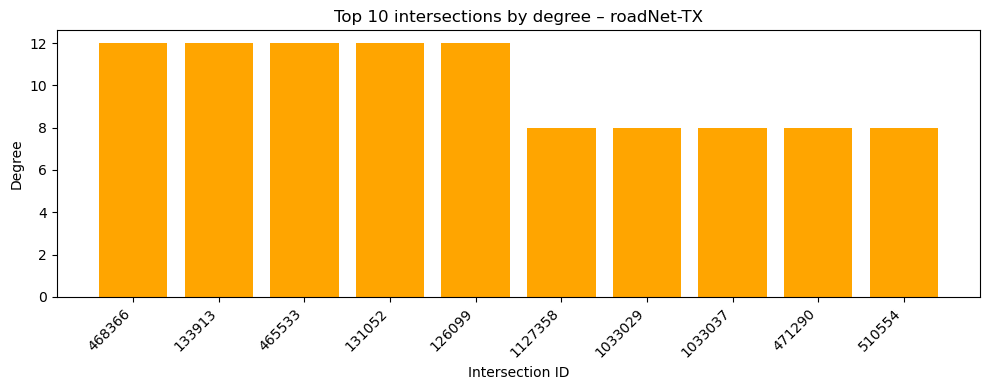

In [26]:
top10_tx = degree_tx_df.orderBy(col("degree").desc()).limit(10).toPandas()

plt.figure(figsize=(10,4))
plt.bar(top10_tx["id"].astype(str), top10_tx["degree"], color="orange")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 intersections by degree – roadNet-TX")
plt.xlabel("Intersection ID")
plt.ylabel("Degree")
plt.tight_layout()
plt.show()

In both states, the intersection with the greater number of connection is 12. However, for Texas, there is more intersection with 12 connections. This certainly depicts bigger hubs in Texas which is consistent with states with bigger area.

###### **Connected components**

The question we asked ourselves was then, how many connected regions the Texas road network contain and if is there a giant component as in California.

For Texas we run 5 iterations of the same label-propagation algorithm.
This gives an approximate view of connected components, which is sufficient for our comparison.

In [27]:
# initial components: each node is its own component
components_tx = vertices_tx.withColumn("component", col("id"))

# undirected edges in both directions
edges_undirected_tx = edges_final_tx.unionByName(
    edges_final_tx.select(col("dst").alias("src"), col("src").alias("dst"))
)

changed = True
iteration = 0

while changed and iteration < 10:
    iteration += 1
    print(f"TX - Iteration {iteration}...")

    # propagate component ids along edges
    propagated_tx = edges_undirected_tx.join(
        components_tx,
        edges_undirected_tx.src == components_tx.id,
        "inner"
    ).select(
        col("dst").alias("id"),
        col("component")
    )

    # for each node, choose smallest reachable component
    min_components_tx = propagated_tx.groupBy("id").agg(
        F.min("component").alias("new_component")
    )

    # join with old components
    updated_tx = components_tx.join(min_components_tx, "id", "left")

    # count changes
    changes_tx = updated_tx.filter(col("component") != col("new_component")).count()
    print(f"  Changes this iteration: {changes_tx}")

    changed = changes_tx > 0

    # update component labels
    components_tx = updated_tx.withColumn(
        "component",
        F.coalesce(col("new_component"), col("component"))
    ).select("id", "component")

# component size summary
component_sizes_tx = components_tx.groupBy("component").count().orderBy(col("count").desc())
component_sizes_tx.show(10)


StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 29, Finished, Available, Finished)

TX - Iteration 1...
  Changes this iteration: 1379917
TX - Iteration 2...
  Changes this iteration: 1356931
TX - Iteration 3...
  Changes this iteration: 1312030
TX - Iteration 4...
  Changes this iteration: 1251727
TX - Iteration 5...
  Changes this iteration: 1181608
TX - Iteration 6...
  Changes this iteration: 1107541
TX - Iteration 7...
  Changes this iteration: 1033050
TX - Iteration 8...
  Changes this iteration: 962233
TX - Iteration 9...
  Changes this iteration: 895269
TX - Iteration 10...
  Changes this iteration: 834991
+---------+-----+
|component|count|
+---------+-----+
|   239187|  673|
|   141881|  614|
|  1144027|  610|
|   709076|  571|
|   801127|  561|
|   259277|  537|
|   202156|  526|
|   141232|  526|
|    66433|  524|
|   140278|  513|
+---------+-----+
only showing top 10 rows



StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 30, Finished, Available, Finished)

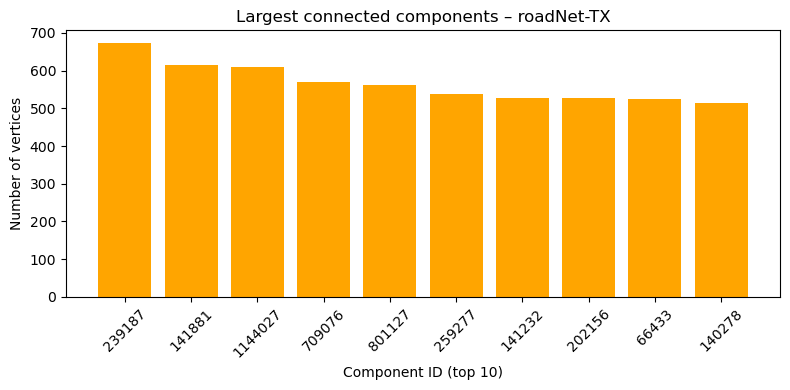

In [28]:
pdf_comp_tx = component_sizes_tx.limit(10).toPandas()

plt.figure(figsize=(8,4))
plt.bar(range(len(pdf_comp_tx)), pdf_comp_tx["count"], color="orange")
plt.xticks(range(len(pdf_comp_tx)), pdf_comp_tx["component"].astype(str), rotation=45)
plt.title("Largest connected components – roadNet-TX")
plt.xlabel("Component ID (top 10)")
plt.ylabel("Number of vertices")
plt.tight_layout()
plt.show()

The bar chart shows the sizes of the 10 largest connected components. And as for California, we observe one giant component containing most vertices, plus several small components.

###### **Number of road segment aligned (2-step paths) and triangle motifs**

To compare the number of triangles of Texas compared to the California network, we first computed the 2-step paths (A → B → C) that exist in the Texas network.

In [29]:
path2_tx = (
    edges_final_tx.alias("e1")
    .join(edges_final_tx.alias("e2"), col("e1.dst") == col("e2.src"))
    .select(
        col("e1.src").alias("A"),
        col("e1.dst").alias("B"),
        col("e2.dst").alias("C")
    )
)

print("Number of A→B→C paths (TX):", path2_tx.count())
path2_tx.show(10)


StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 31, Finished, Available, Finished)

Number of A→B→C paths (TX): 2150171
+----+----+-----+
|   A|   B|    C|
+----+----+-----+
|   3|   4|   19|
| 232|4998| 5343|
|9420|9442| 9445|
| 379|9442| 9445|
| 602| 739|11019|
| 731| 739|11019|
| 948|1125| 1272|
|1124|1125| 1272|
|1123|1125| 1272|
|1089|1151| 1152|
+----+----+-----+
only showing top 10 rows



To count the number of triangles, we use the same undirected triangle detection algorithm as for the California road network.

In [30]:
# Step 0: start from undirected unique edges: src < dst
ab_tx = edges_final_tx.select(col("src").alias("a"), col("dst").alias("b"))

# Step 1: find pairs of edges sharing 'a': (a,b) and (a,c) with b < c
ab_ab_tx = (
    ab_tx.alias("ab1")
        .join(
            ab_tx.alias("ab2"),
            (col("ab1.a") == col("ab2.a")) & (col("ab1.b") < col("ab2.b"))
        )
)

tri_candidates_tx = ab_ab_tx.select(
    col("ab1.a").alias("a"),
    col("ab1.b").alias("b"),
    col("ab2.b").alias("c")
)

# Step 2: keep only those where edge (b,c) exists
triangles_tx = (
    tri_candidates_tx.alias("t")
        .join(
            ab_tx.alias("bc"),
            (col("t.b") == col("bc.a")) & (col("t.c") == col("bc.b"))
        )
        .select(
            col("t.a").alias("a"),
            col("t.b").alias("b"),
            col("t.c").alias("c")
        )
        .distinct()
)

tri_tx_count = triangles_tx.count()
print("Number of undirected triangles (TX):", tri_tx_count)
triangles_tx.show(10)

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 32, Finished, Available, Finished)

Number of undirected triangles (TX): 82869
+-----+-----+------+
|    a|    b|     c|
+-----+-----+------+
| 1811| 1816|  1817|
|13718|13838| 13954|
|14810|14812| 14815|
|15647|15658| 15668|
|30445|30447| 30541|
|42435|42436| 42439|
|44398|44810|117434|
|50343|50344| 50345|
|52718|52719| 52740|
|29789|30038| 82336|
+-----+-----+------+
only showing top 10 rows



To make it easily comparable, we plotted the results of bith California and Texas.

StatementMeta(, 22c47bec-b452-427b-8348-712c0bafc07e, 33, Finished, Available, Finished)

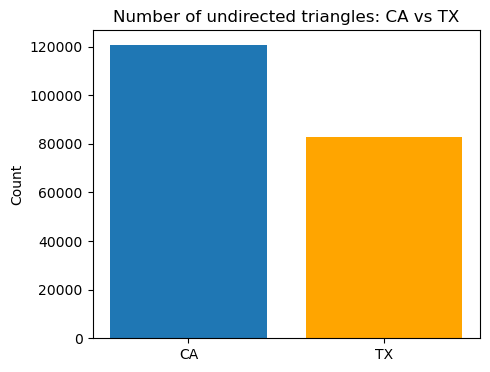

In [31]:
triangles_ca = 120676
triangles_tx = tri_tx_count

plt.figure(figsize=(5,4))
plt.bar(["CA", "TX"], [triangles_ca, triangles_tx], color=["tab:blue", "orange"])
plt.title("Number of undirected triangles: CA vs TX")
plt.ylabel("Count")
plt.show()

We compare the total number of undirected triangles in the two road networks. California has 120,676 triangles and Texas has 82,869 traingles. 

The values are of the same order of magnitude (frequency), which suggests that both networks share similar local clustering behavior.

###### **Conclusion**

To wrap everything up, both states road graphs look structurally alike. Indeed, they contain many low-degree intersections, a small tail of busy hubs and a single giant connected component. All our findings depicts realistic street networks. Where they diverge is local clustering. Triangle counts suggest differences in how tightly streets mesh (denser urban grids vs. more tree-like layouts) but the difference is not tremendous. 

In short, California and Texas share the same global geometry but vary in local street fabric and the heaviest junctions, reflecting urban form and planning history.

An interesting add we could make to our study is a spacial density to observe differences between the center and the suburbs for instance.